# Random Forest Classifier from Scratch

This notebook implements a Random Forest Classifier from scratch by bagging multiple Decision Trees.

## Mathematical/Algorithmic Intuition
1. Create $N$ bootstrap samples from the training set.
2. Train a Decision Tree on each bootstrap sample.
3. At each split in a tree, only consider a random subset of features (feature bagging).
4. Predict by taking the majority vote of predictions from all individual trees.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

np.random.seed(42)

## Generate Dataset

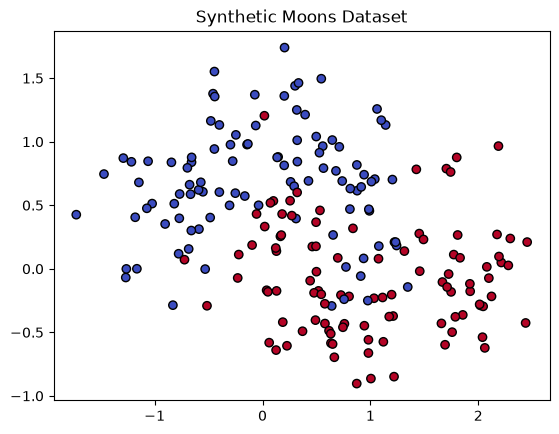

In [2]:
X, y = make_moons(n_samples=200, noise=0.3, random_state=42)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k')
plt.title('Synthetic Moons Dataset')
plt.show()

## Base Decision Tree Implementation (with Feature Bagging option)

In [3]:
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, *, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value
        
    def is_leaf(self):
        return self.value is not None

class RandomDecisionTree:
    def __init__(self, max_depth=5, min_samples_split=2, max_features=None):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.root = None
        
    def fit(self, X, y):
        self.root = self._grow_tree(X, y)
        
    def _grow_tree(self, X, y, depth=0):
        n_samples, n_features = X.shape
        n_labels = len(np.unique(y))
        
        if (depth >= self.max_depth or
            n_labels == 1 or
            n_samples < self.min_samples_split):
            leaf_value = self._most_common_label(y)
            return Node(value=leaf_value)
            
        # Feature Bagging: select random features
        feat_indices = np.random.choice(n_features, self.max_features, replace=False) if self.max_features else np.arange(n_features)
        
        best_feat, best_thresh = self._best_split(X, y, n_samples, feat_indices)
        
        if best_feat is None:
            return Node(value=self._most_common_label(y))
            
        left_idx = X[:, best_feat] < best_thresh
        right_idx = ~left_idx
        
        left = self._grow_tree(X[left_idx], y[left_idx], depth+1)
        right = self._grow_tree(X[right_idx], y[right_idx], depth+1)
        return Node(feature=best_feat, threshold=best_thresh, left=left, right=right)
        
    def _best_split(self, X, y, n_samples, feat_indices):
        best_gain = -1
        split_idx, split_thresh = None, None
        
        for feat_idx in feat_indices:
            X_column = X[:, feat_idx]
            thresholds = np.unique(X_column)
            for threshold in thresholds:
                gain = self._information_gain(y, X_column, threshold)
                if gain > best_gain:
                    best_gain = gain
                    split_idx = feat_idx
                    split_thresh = threshold
                    
        return split_idx, split_thresh
        
    def _information_gain(self, y, X_column, threshold):
        parent_entropy = self._entropy(y)
        left_idx = X_column < threshold
        right_idx = ~left_idx
        if len(y[left_idx]) == 0 or len(y[right_idx]) == 0:
            return 0
        n = len(y)
        n_l, n_r = len(y[left_idx]), len(y[right_idx])
        e_l, e_r = self._entropy(y[left_idx]), self._entropy(y[right_idx])
        child_entropy = (n_l / n) * e_l + (n_r / n) * e_r
        return parent_entropy - child_entropy
        
    def _entropy(self, y):
        hist = np.bincount(y)
        ps = hist / len(y)
        return -np.sum([p * np.log2(p) for p in ps if p > 0])
        
    def _most_common_label(self, y):
        return np.bincount(y).argmax()
        
    def predict(self, X):
        return np.array([self._traverse_tree(x, self.root) for x in X])
        
    def _traverse_tree(self, x, node):
        if node.is_leaf():
            return node.value
        if x[node.feature] < node.threshold:
            return self._traverse_tree(x, node.left)
        return self._traverse_tree(x, node.right)

## Random Forest Implementation

In [4]:
class RandomForestFromScratch:
    def __init__(self, n_estimators=10, max_depth=5, min_samples_split=2, max_features=None):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.trees = []
        
    def fit(self, X, y):
        self.trees = []
        n_samples = X.shape[0]
        
        for _ in range(self.n_estimators):
            # Bootstrap sample
            indices = np.random.choice(n_samples, n_samples, replace=True)
            X_bootstrap, y_bootstrap = X[indices], y[indices]
            
            # Fit tree
            tree = RandomDecisionTree(max_depth=self.max_depth, 
                                      min_samples_split=self.min_samples_split,
                                      max_features=self.max_features)
            tree.fit(X_bootstrap, y_bootstrap)
            self.trees.append(tree)
            
    def predict(self, X):
        # Gather predictions from all trees
        tree_preds = np.array([tree.predict(X) for tree in self.trees])
        # Take majority vote for each sample
        # tree_preds is shape (n_estimators, n_samples)
        # We transpose it to shape (n_samples, n_estimators) to vote along axis=1
        votes = [np.bincount(sample_preds).argmax() for sample_preds in tree_preds.T]
        return np.array(votes)

## Evaluate Model & Plot Decision Boundary

Random Forest Training Accuracy: 97.50%


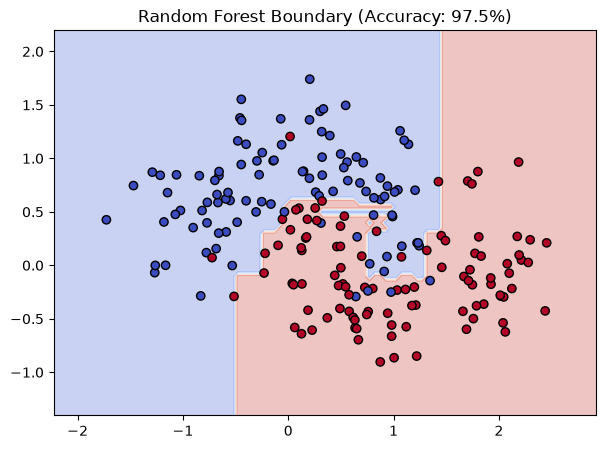

In [5]:
forest = RandomForestFromScratch(n_estimators=20, max_depth=6, max_features=2)
forest.fit(X, y)

y_pred = forest.predict(X)
accuracy = np.mean(y_pred == y)
print(f"Random Forest Training Accuracy: {accuracy * 100:.2f}%")

# Grid for boundary
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05), np.arange(y_min, y_max, 0.05))
Z = forest.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(7, 5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k')
plt.title(f'Random Forest Boundary (Accuracy: {accuracy*100:.1f}%)')
plt.show()